# Vlasov-Poisson Mirror Model for Plasma Confinement (single-species regime)

## Optimal confinement example

We study attempt to find an optimal configuration of the magnetic field $\mathbf{B}$ to maximize plasma confinement. 

### Imports

In [1]:
import numpy as np
import jax
jax.config.update("jax_enable_x64", True)
Array = jax.Array
import jax.numpy as jnp

import optax
import equinox as eqx
from tqdm import tqdm

from vp_solver.jax_mirror_solver import make_mesh, VlasovPoissonSolver
from vp_solver.utils_mirror import BFieldMLP, load_b_trained, step_single
from vp_solver.utils_mirror import get_initial_distribution_single

# Plotting imports
from vp_solver.utils_plots import plot_magnetic_fields, plot_initial_distribution_single
from vp_solver.utils_plots import plot_final_distribution_single, plot_energies_single
from vp_solver.utils_plots import plot_rhos_single, plot_int_rho_single, plot_summray_opt_single


### Problem and solver setup

Our goal is to find the optimal $\mathbf{B}$ which is parametrized through a multi-layer perceptron (MLP) such that $|\mathbf{B}(z)|:= \mathcal{N}(z;\theta)$. This becomes a PDE-constrained optimization problem defined as

$$
\max_{\theta} \, \mathcal{J}(\theta)
$$

subject to the following Vlasov-Poisson system

$$\partial_t f_e
+
v\partial_z f_e
+
\left(
\frac{q_e}{m_e}E(t,z)
-
\mu \partial_z |\mathbf{B}(z)|
\right)\partial_v f_e
=
0,
$$

where
- $f_e(t,z,v,\mu)$ is the electron distribution,
- $q_e$ is the electron's charge,
- $m_e$ is the electron's mass,
- $\mathbf{B}(z)$ is the magnetic field,
- $E(t,z)$ is the electric field,
- $z \in [-L_z,L_z]$, $v \in \mathbb{R}$, $\mu\in\mathbb{R}_{+}$ and $t\in \mathbb{R}_{+}$.

The electric field is defined as $E(t,z) = -\partial_z \phi(t,z)$ where $\phi$ represents the electric potential and is obtained by solving the following Poisson equation:

$$\left\{\begin{array}{rcl}
-\partial_{zz}\phi
+
\partial_z\phi
\frac{\partial_z |\mathbf{B}(z)|}{|\mathbf{B}(z)|}
& = &
2\pi |\mathbf{B}(z)|
\iint
\left(
f_e(t=0) - f_e
\right)
\,\mathrm{d}v\,\mathrm{d}\mu, \\
\phi(t,-L_z)
=
\phi(t,L_z)
&=&
0.
\end{array}
\right.
$$

We solve this Vlasov-Poisson system using a conservative semi-Lagrangian scheme with Strang operator splitting for time advancement.

We chose our objective functional $\mathcal{J}$ as follows

$$\mathcal{J}(\theta) = \int_{-L_z}^{L_z}\rho^{1D}_{e}(t,z;,\theta)\,\mathrm{d}z$$

where

$$
\rho_e^{1D}(t,z)
=
\iint
f_e(t,z,v,\mu)
\,\mathrm{d}v\,\mathrm{d}\mu\,.
$$




In [2]:
# Setup for the forward solver
nz = 128
nv = 128
nmu = 128
dt = 0.1
t_final = 25.0
t_values = jnp.linspace(0, t_final, int(t_final / dt)+1)
LZ = 2*jnp.pi
LV = 4.0
LMU = 2.8 # Given that B_max = 10.0
zs = jnp.linspace(-LZ, LZ, nz, endpoint=True)

mesh = make_mesh(length_z=LZ, 
    length_v=LV, length_mu=LMU,
    nz=nz, nv=nv, nmu=nmu
)

sigma_z = 0.8

## B parameters
B_max = 10.0
B_min = 1.0


mirror_ratio = B_max/B_min
prop_trapped = jnp.sqrt((mirror_ratio - 1)/mirror_ratio)
print("Particles trapped: {:.3f}".format(prop_trapped))

Particles trapped: 0.949


#### Loading initial magnetic profile $|\mathbf{B}|$ and solver

In [3]:
seed = 0
key = jax.random.PRNGKey(seed)
b_model = BFieldMLP(key, center=0.0)

B_fn_grid_init, dB_fn_grid_init, B_eval_init, dB_eval_init, g_eval_init = load_b_trained(seed, mesh.zs)


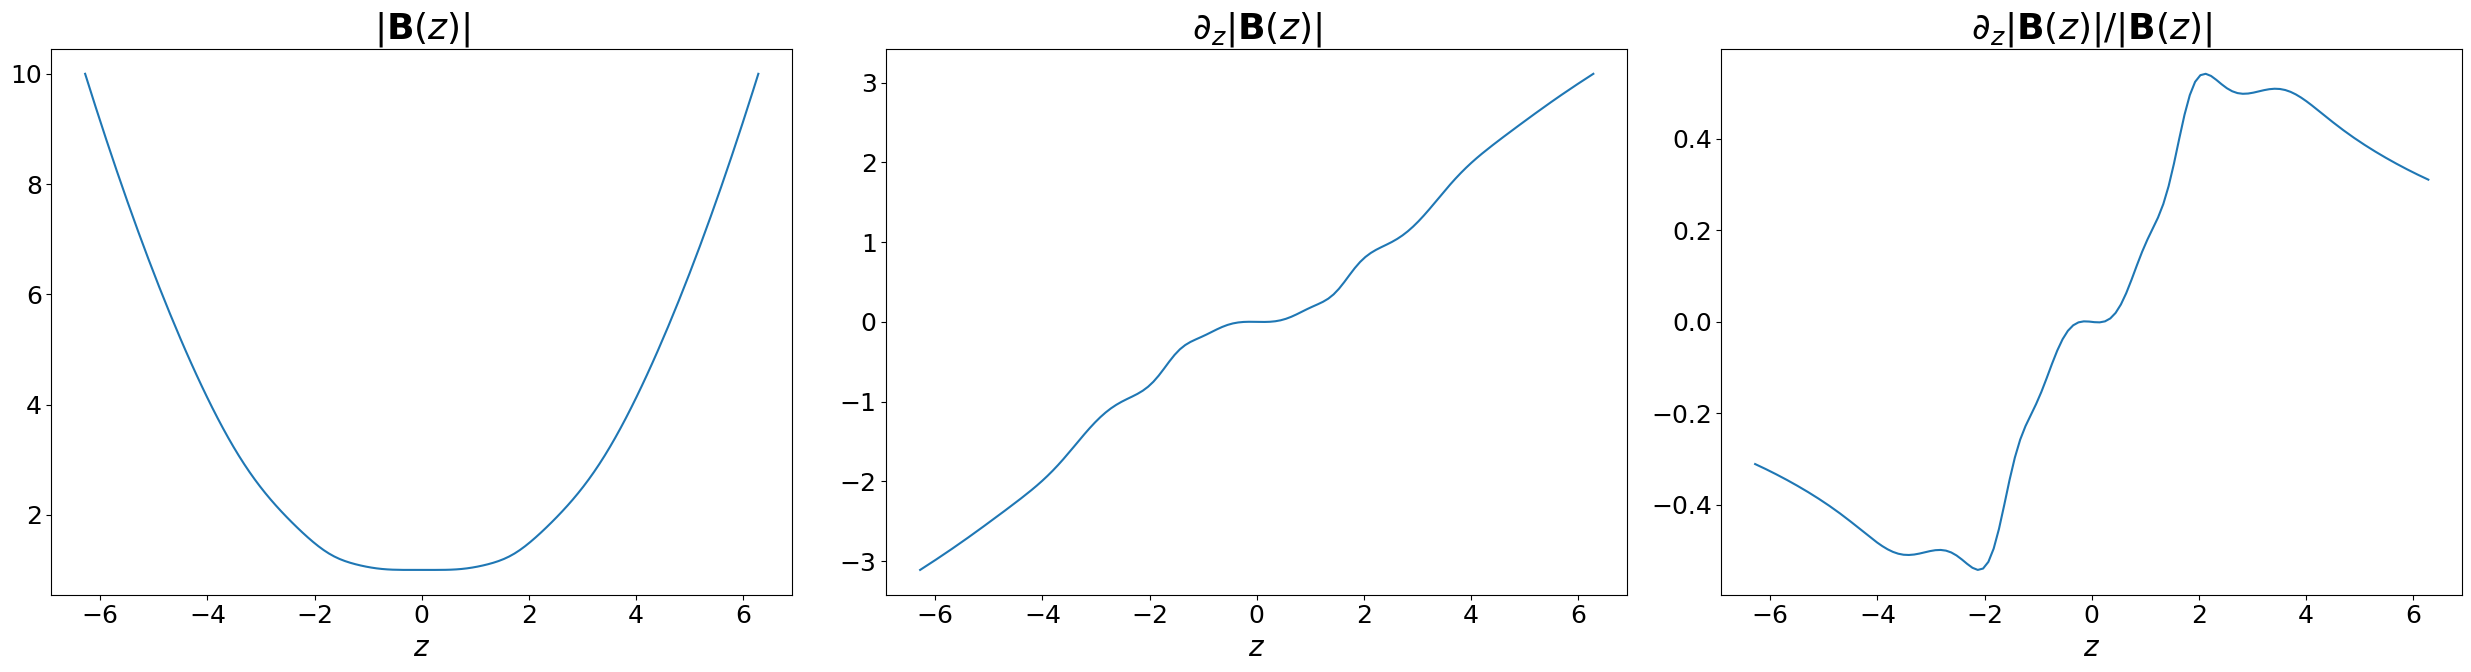

In [4]:
plot_magnetic_fields(B_eval_init, dB_eval_init, g_eval_init, mesh.zs)

We load and plot the initial $f_e$ given our inital magnetic profile guess to compare later.

In [5]:
f_iv_init = get_initial_distribution_single(B_fn_grid_init, sigma_z, mesh)

print("\\int\\rho dz: ", jnp.trapezoid(jnp.trapezoid(jnp.trapezoid(f_iv_init, x=mesh.mus, axis=2), x=mesh.vs, axis=1), x=mesh.zs, axis=0))

\int\rho dz:  1.0


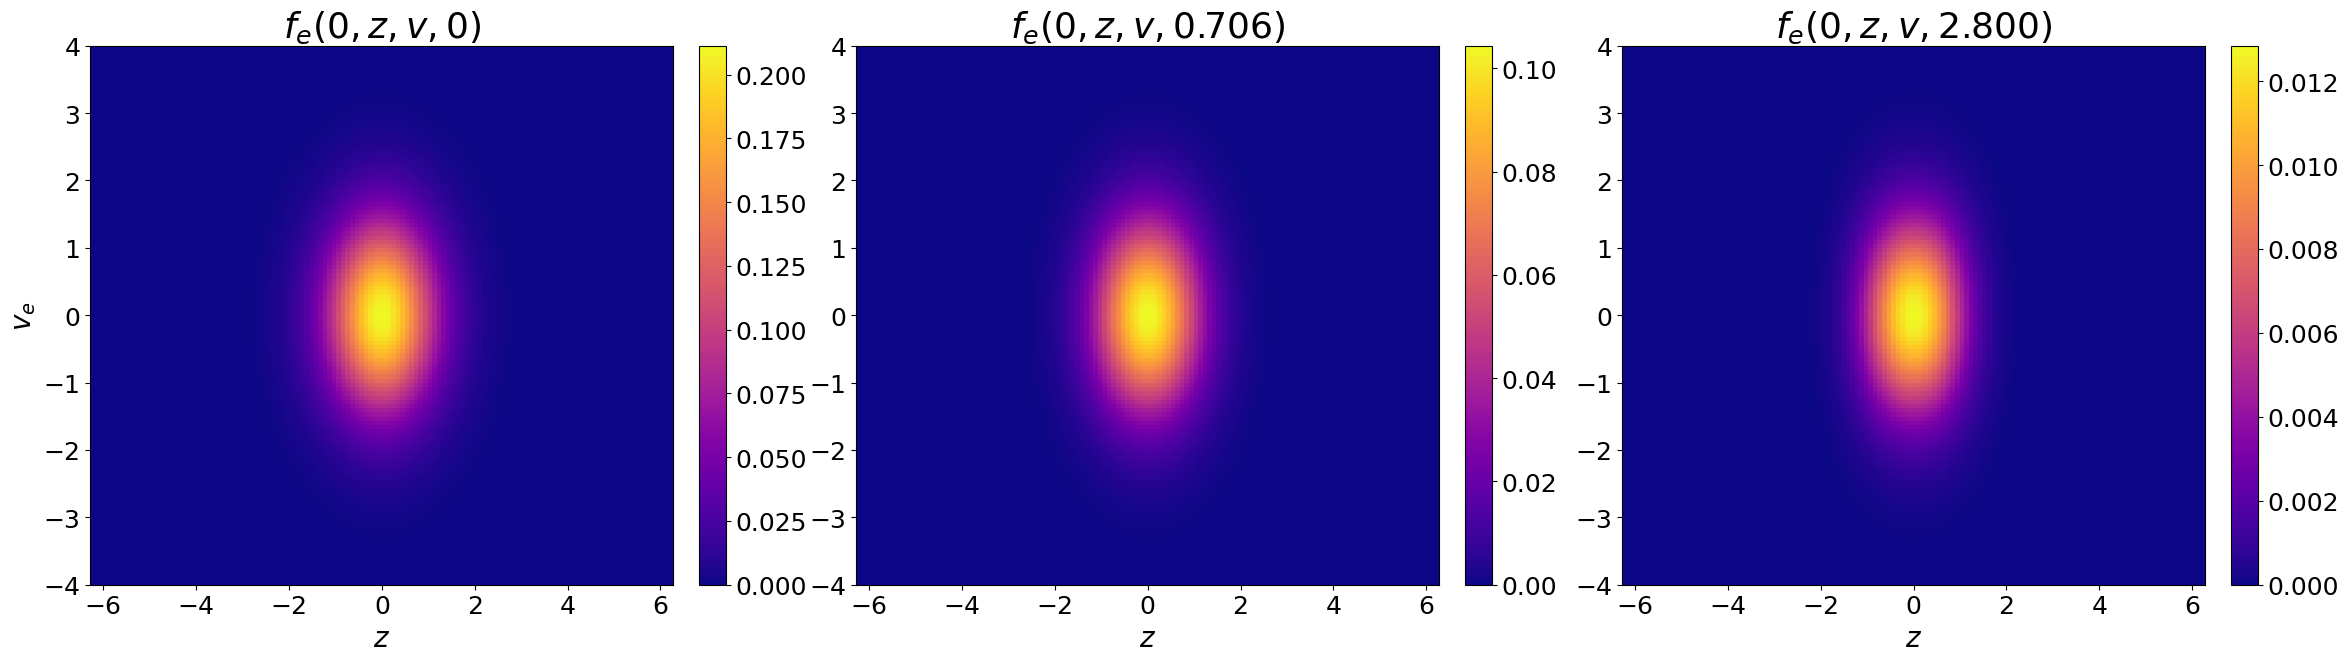

In [6]:
plot_initial_distribution_single(f_iv_init, mesh)

In [7]:
solver = VlasovPoissonSolver(mesh=mesh, dt=dt)

#### Optimization step

Skip if there is an already loaded b field to use.

In [8]:
# Optimizer and opt_state
optimizer = optax.chain(
    optax.clip_by_global_norm(1.0),
    optax.adam(learning_rate=1e-3)
)
opt_state = optimizer.init(eqx.filter(b_model, eqx.is_inexact_array))

def step(model, state):
    return step_single(
        model=model, 
        opt_state=state, 
        optimizer=optimizer, 
        sigma_z=sigma_z, 
        solver=solver, 
        t_final=t_final, 
        mesh=mesh
    )

# Run optimization
epochs = 100
pbar = tqdm(range(epochs), desc="Optimizing B-Field MLP")
for i in pbar:
    b_model, opt_state, loss_val = step(b_model, opt_state)

    # Update the progress bar postfix with the latest loss
    # You can add more metrics here if you track them!
    pbar.set_postfix({"Loss": f"{loss_val:.4e}"})

# The path where you want to save it
save_path = "optimized_b_field_model_single.eqx"
# Serialize the leaves (arrays) of your PyTree
eqx.tree_serialise_leaves(save_path, b_model)
print(f"Model saved successfully to: {save_path}")

Optimizing B-Field MLP:   0%|          | 0/100 [00:00<?, ?it/s]

Optimizing B-Field MLP: 100%|██████████| 100/100 [08:01<00:00,  4.82s/it, Loss=-9.9934e-01]

Model saved successfully to: optimized_b_field_model_single.eqx


#### Loading optimal $|\mathbf{B}|$ profile

In [9]:
load_trained_path = "trained_bfields/optimized_b_field_model_single.eqx"
B_fn_grid_opt, dB_fn_grid_opt, B_eval_opt, dB_eval_opt, g_eval_opt = load_b_trained(0, zs, load_trained_path)

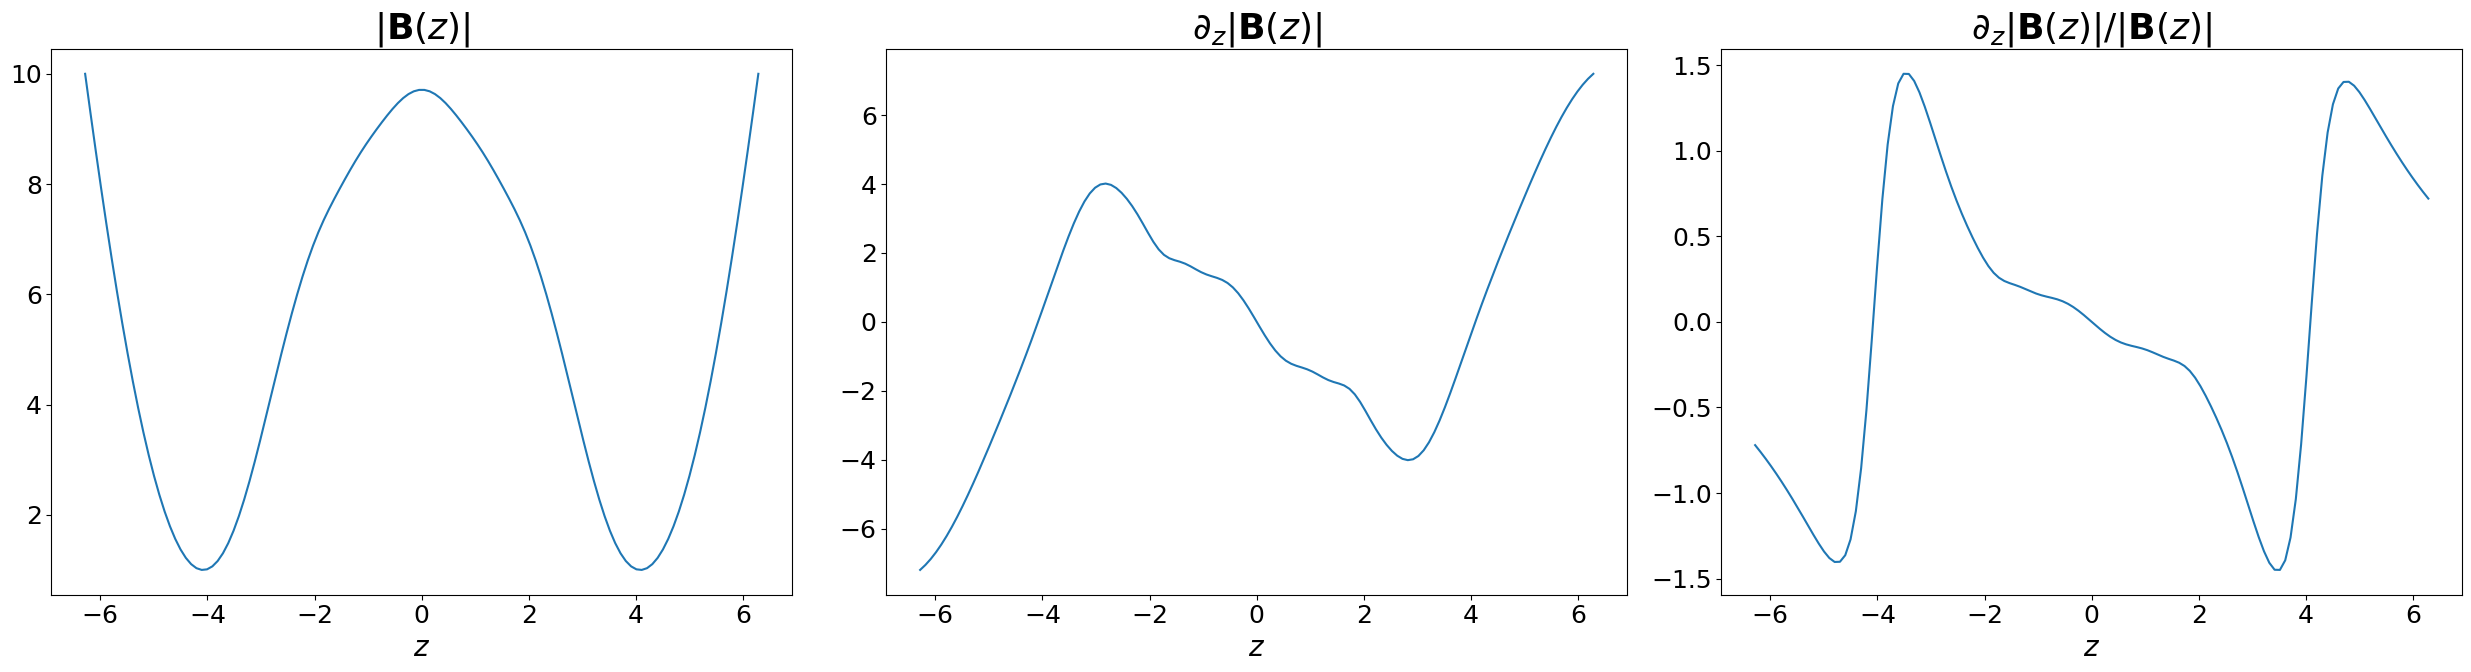

In [10]:
plot_magnetic_fields(B_eval_opt, dB_eval_opt, g_eval_opt, mesh.zs)

We load and plot the initial $f_e$ given our optimal magnetic profile.

In [11]:
f_iv_opt = get_initial_distribution_single(B_fn_grid_opt, sigma_z, mesh)

print("\\int\\rho dz: ", jnp.trapezoid(jnp.trapezoid(jnp.trapezoid(f_iv_opt, x=mesh.mus, axis=2), x=mesh.vs, axis=1), x=mesh.zs, axis=0))

\int\rho dz:  1.0


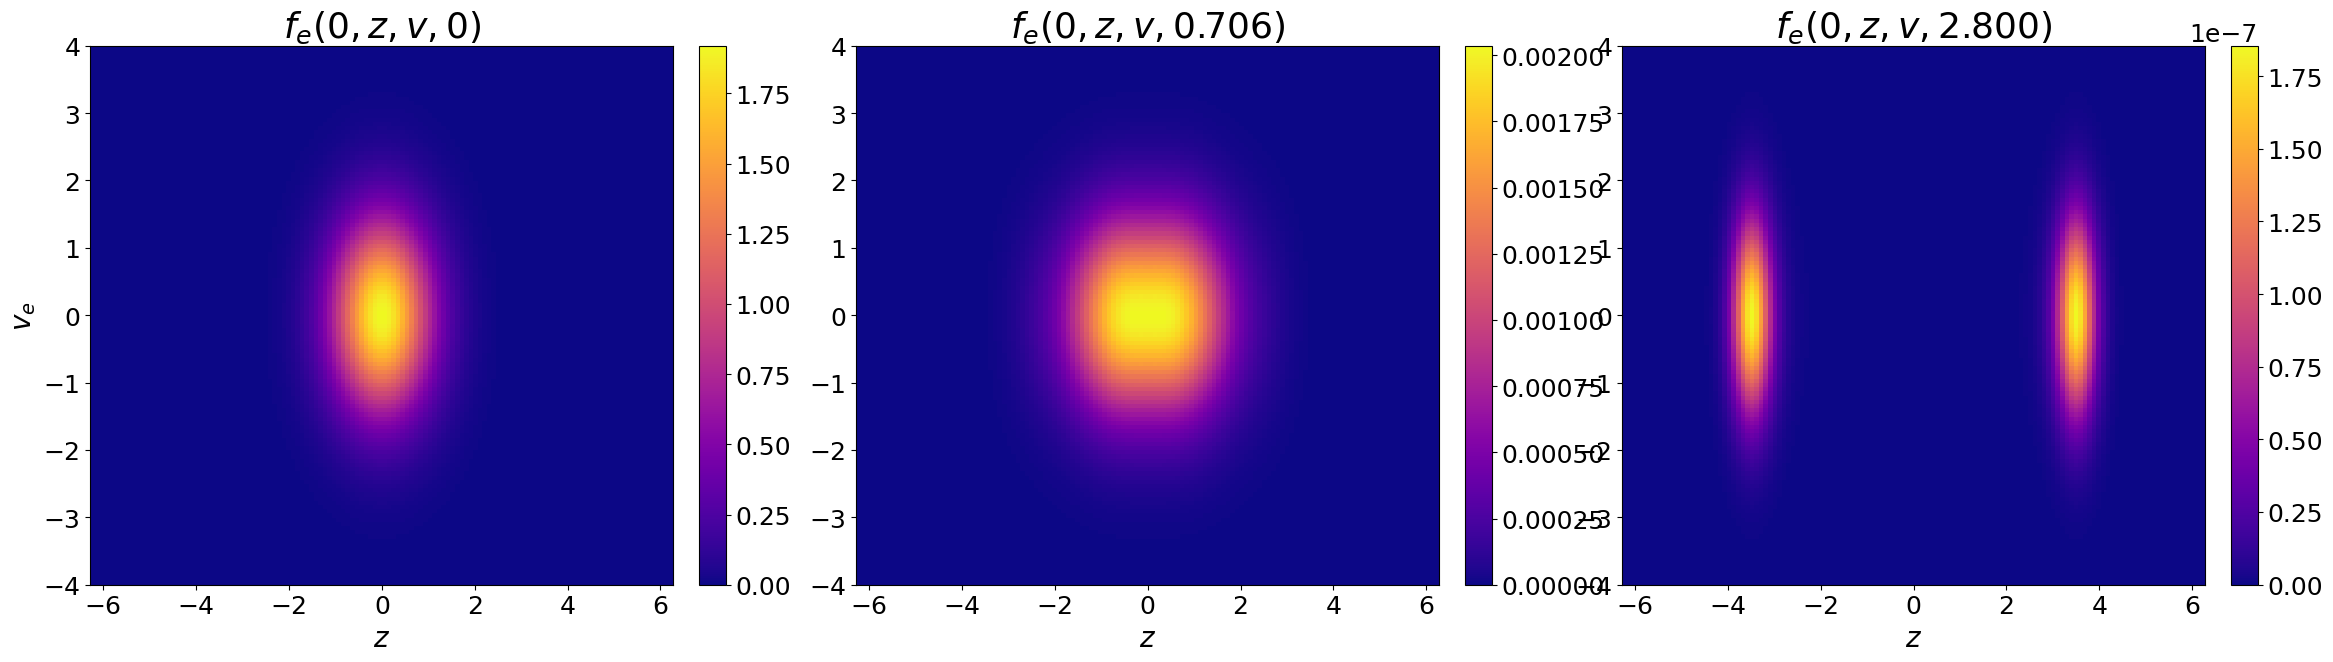

In [12]:
plot_initial_distribution_single(f_iv_opt, mesh)

In [13]:
# JIT-compiled forward solvers
solver_jit = eqx.filter_jit(solver.run_forward_jax_scan)

In [14]:
f_array_opt, f_total_opt, E_array_opt, ee_array_opt, rho_array_opt = solver_jit(f_iv_opt, B_eval_opt, dB_eval_opt, g_eval_opt, t_final=t_final)
f_array_init, f_total_init, E_array_init, ee_array_init, rho_array_init = solver_jit(f_iv_init, B_eval_init, dB_eval_init, g_eval_init, t_final=t_final)

We plot the results: top is using the initial guess configuration for $|\mathbf{B}|$ and bottom is using the optimal one.

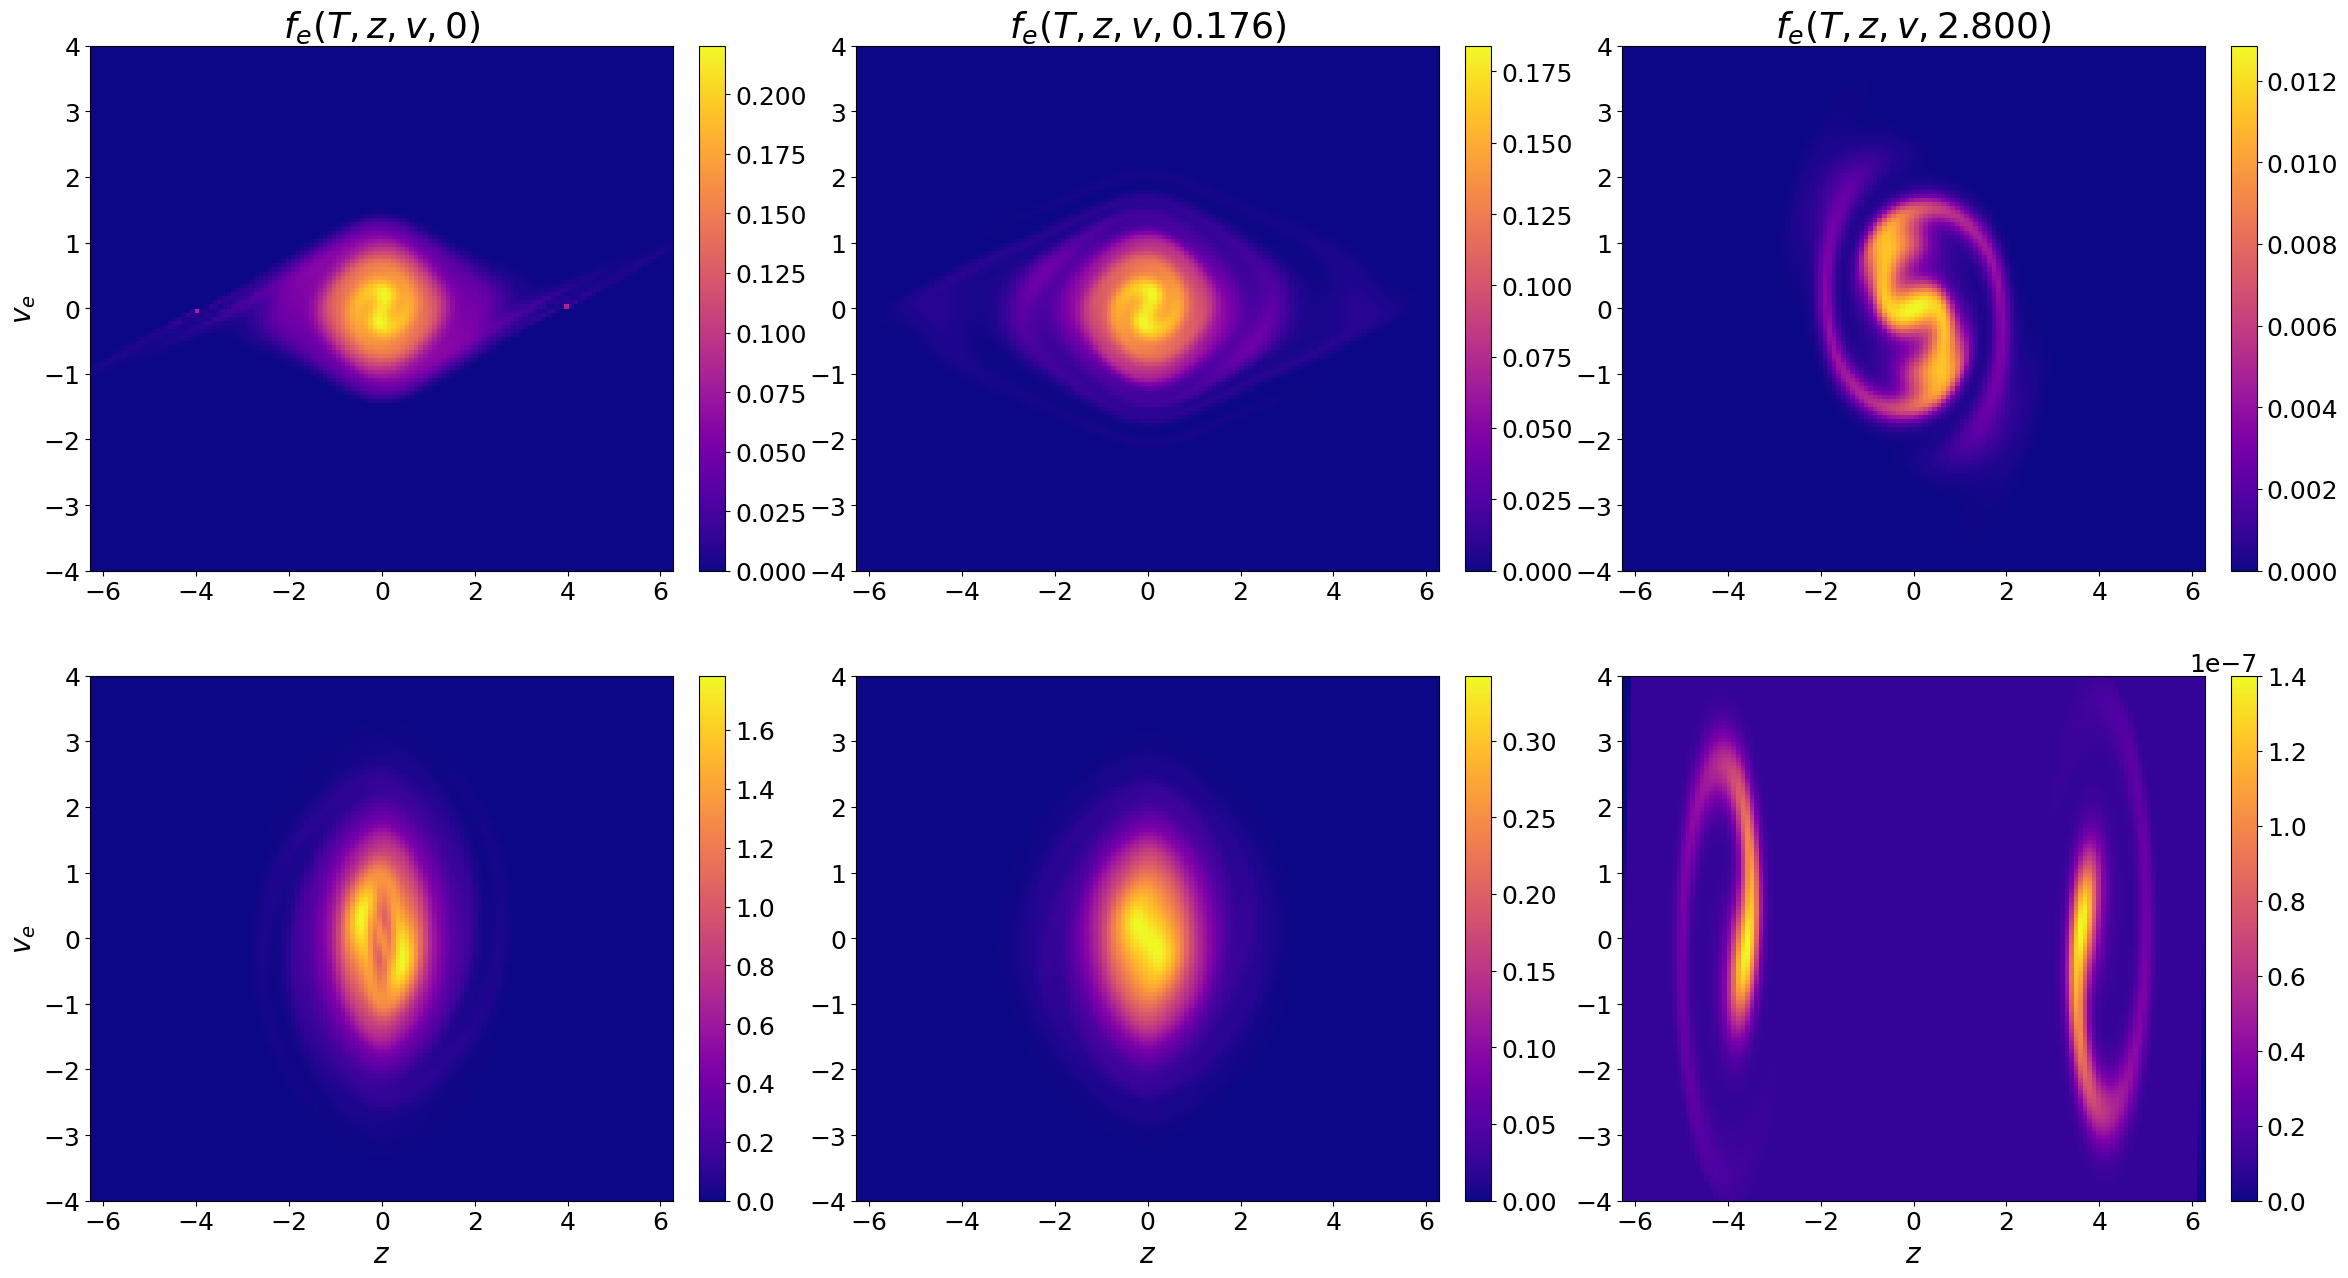

In [15]:
plot_final_distribution_single(f_array_init, f_array_opt, mesh)

We plot the electrical energy $\mathcal{E}(t)$ defined as

$$
\mathcal{E}(t) = \frac{1}{2}\int_{-L_z}^{L_z}E(t,z)^{2}\,\mathrm{d}z\,. 
$$

for both configurations (top: initial; bottom: optimal).

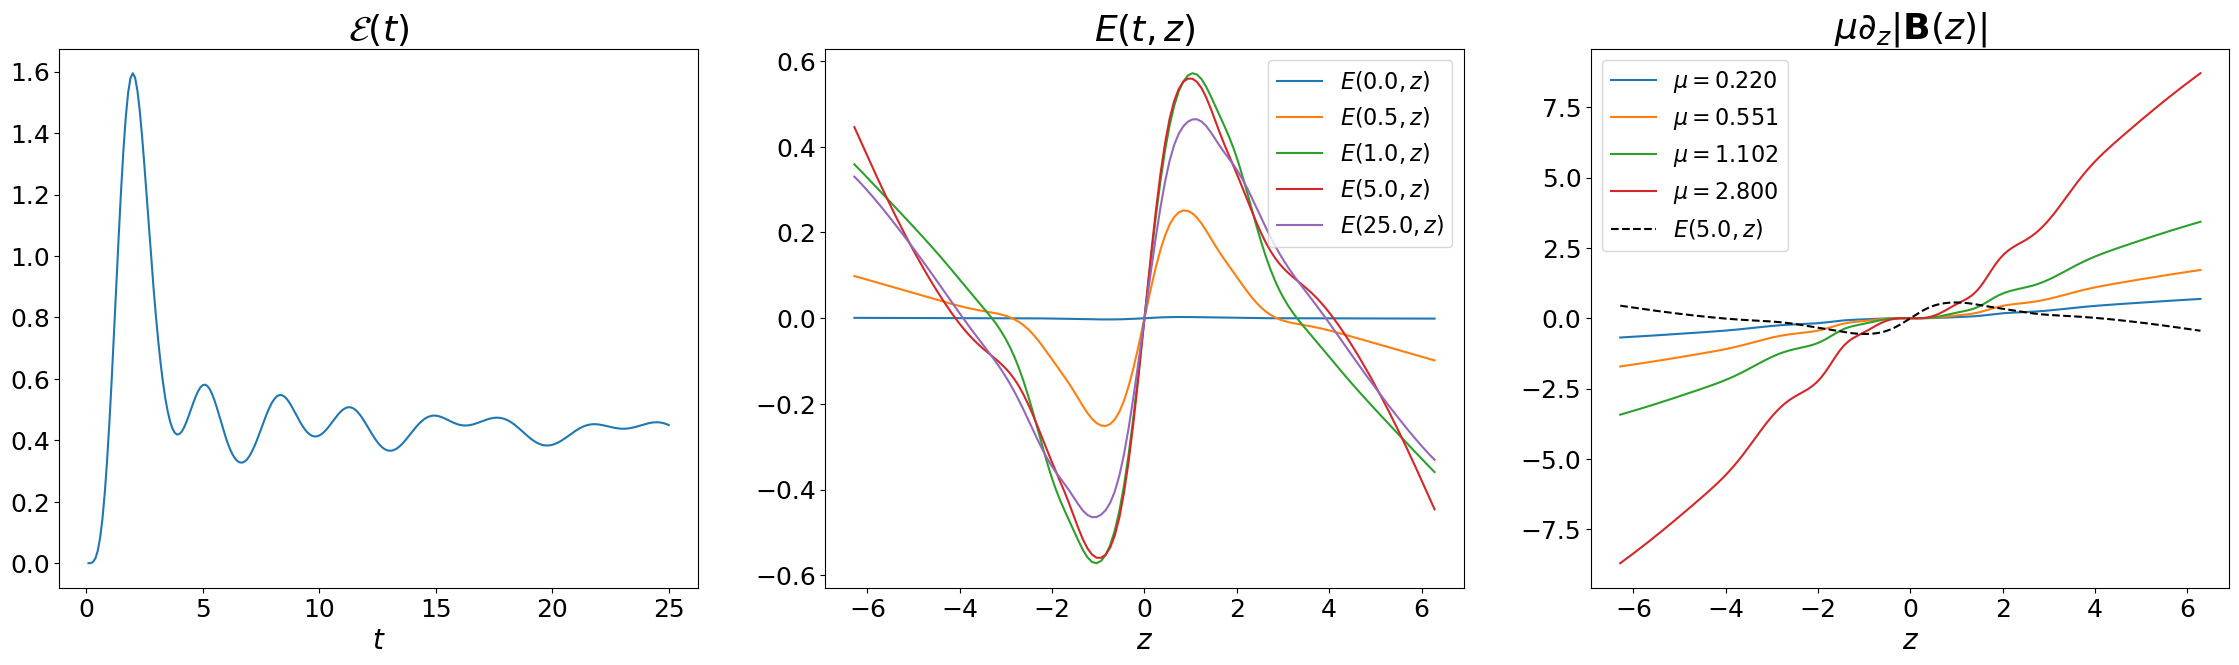

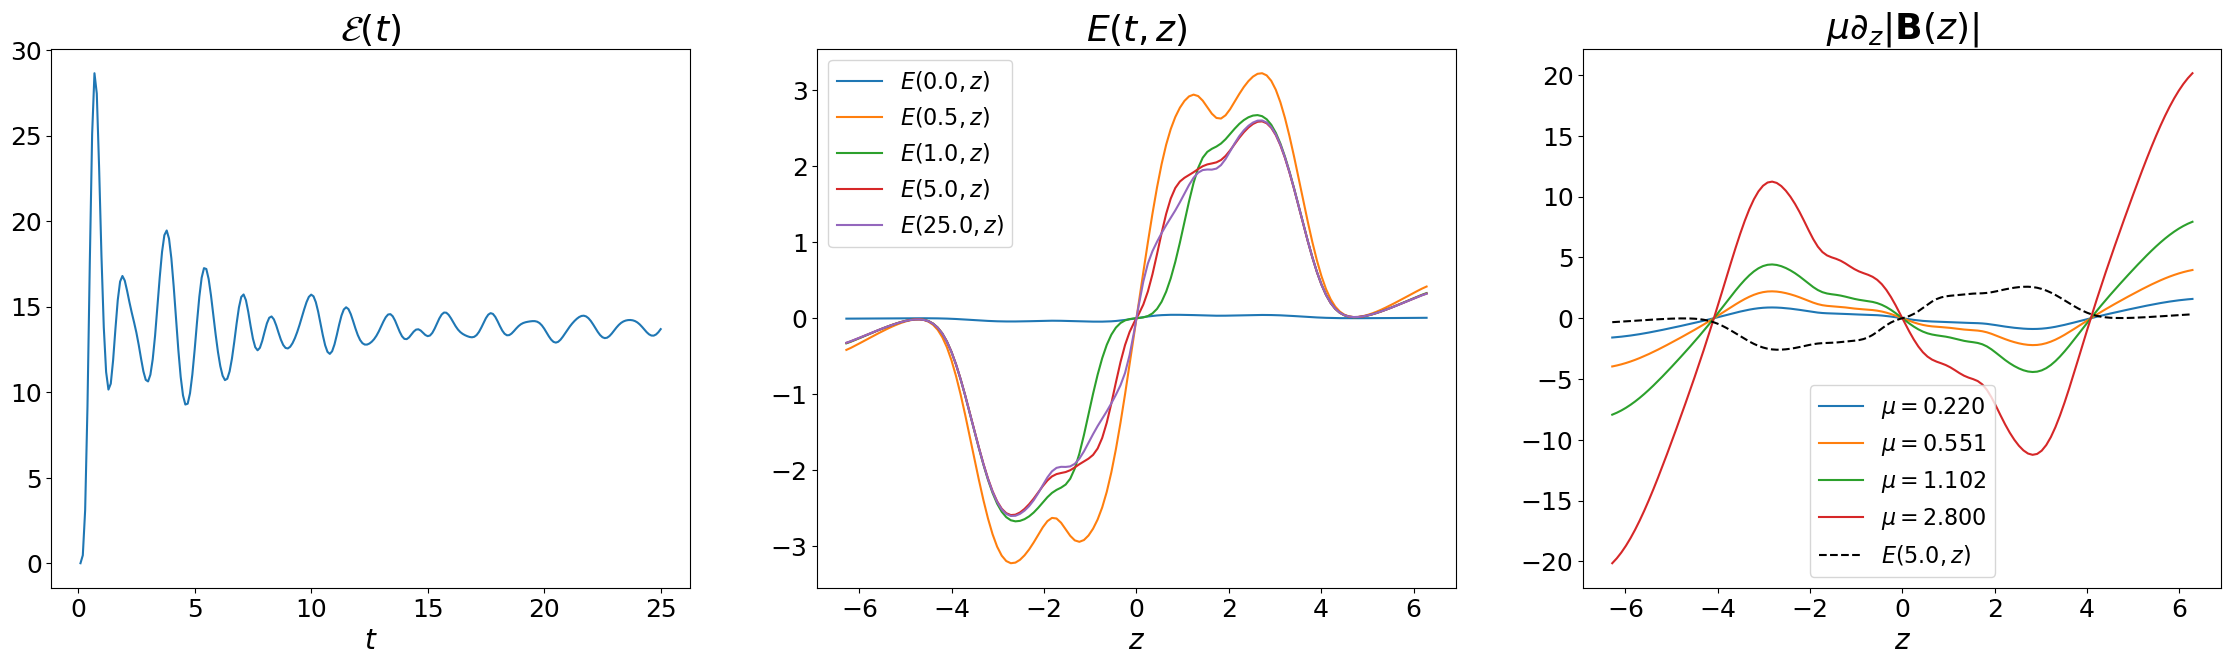

In [16]:
plot_energies_single(t_values, ee_array_init, E_array_init, dB_eval_init, mesh)
plot_energies_single(t_values, ee_array_opt, E_array_opt, dB_eval_opt, mesh)

We plot two density quantities: the three-dimensional density, which is given by
$$
\rho_e(t,z)
=
2\pi |\mathbf{B}(z)|
\iint
f_e(t,z,v,\mu)
\,\mathrm{d}v\,\mathrm{d}\mu\,,
$$
and the effective longitudinal density, which is given by
$$
\rho_e^{1D}(t,z)
=
\iint
f_e(t,z,v,\mu)
\,\mathrm{d}v\,\mathrm{d}\mu\,.
$$

In addition, to see the level of confinement in time we plot

$$\int_{-L_z}^{L_z}\rho_e^{1D}(t,z)\,\mathrm{d}z\,.$$

For every block top is the initial guess and bottom is the optimal configuration for $|\mathbf{B}|$.

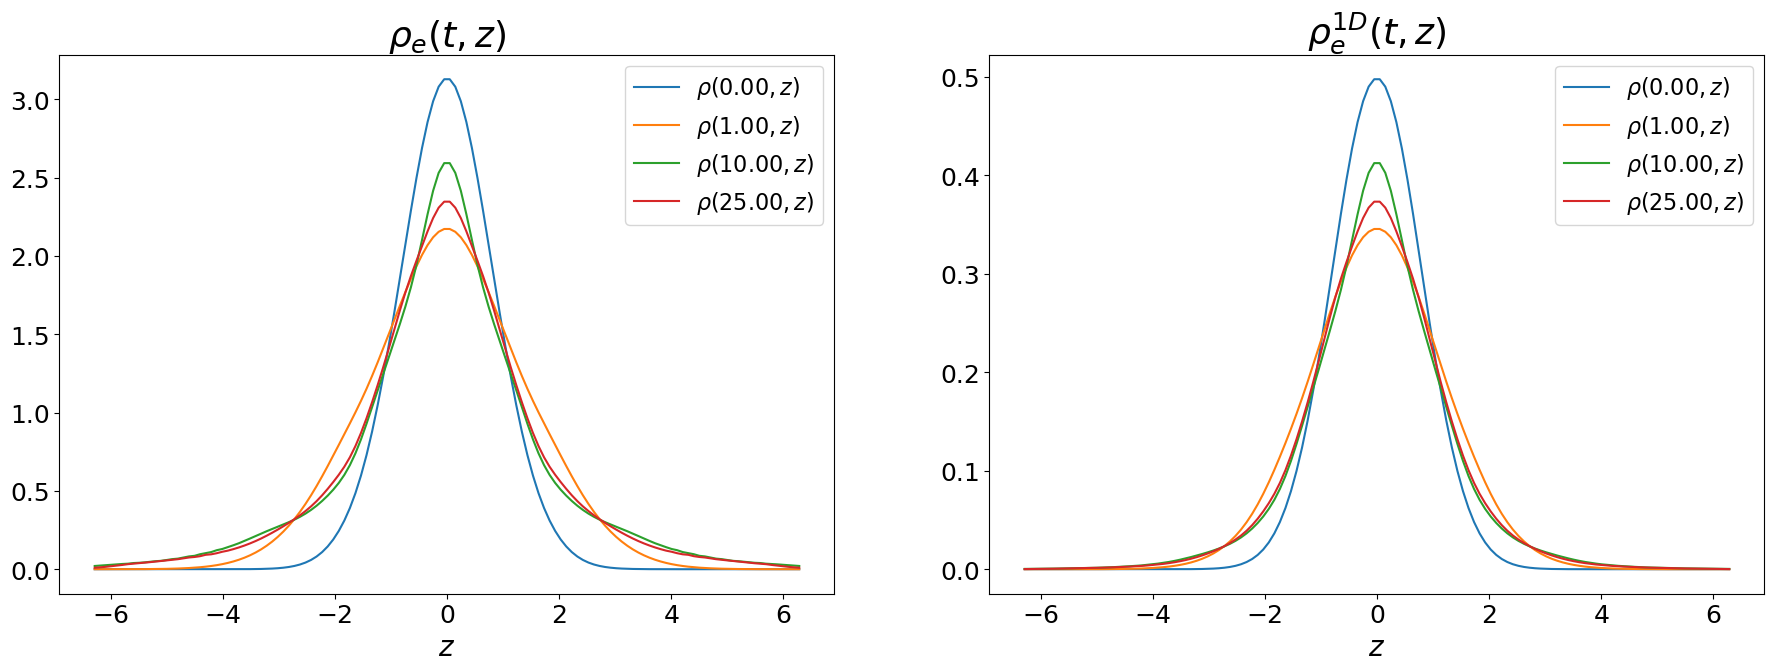

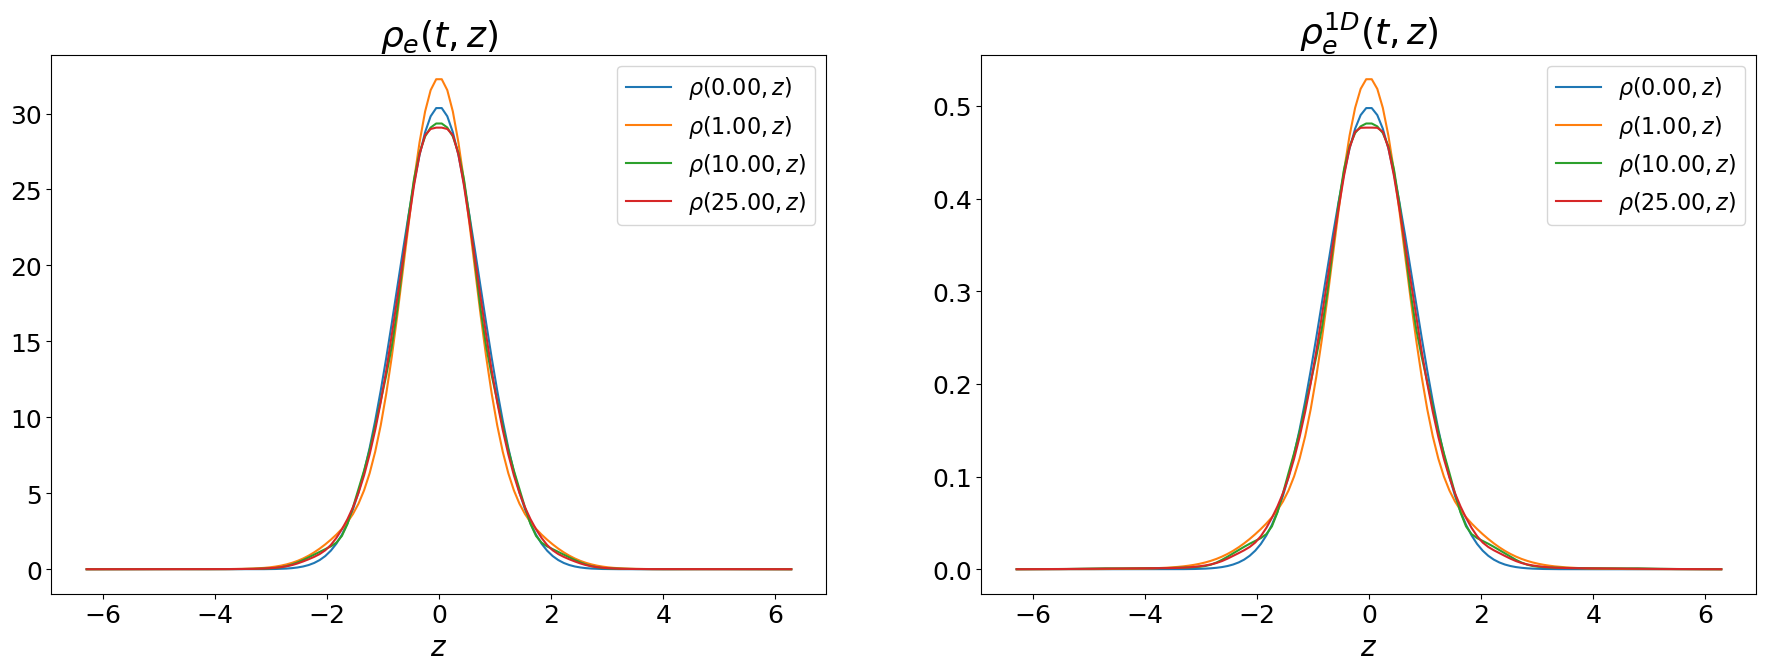

In [17]:
plot_rhos_single(rho_array_init, B_eval_init, t_values, mesh)
plot_rhos_single(rho_array_opt, B_eval_opt, t_values, mesh)

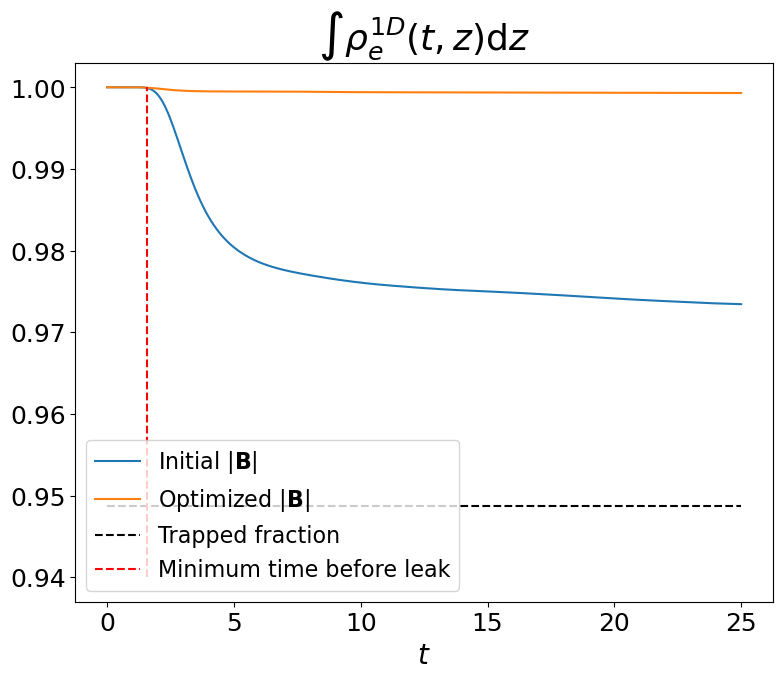

In [18]:
plot_int_rho_single(rho_array_init, rho_array_opt, t_values, LZ, LV, prop_trapped, mesh)

We plot a summary of the results below with only the electric field and $\rho_e^{1D}$ for the optimal case.

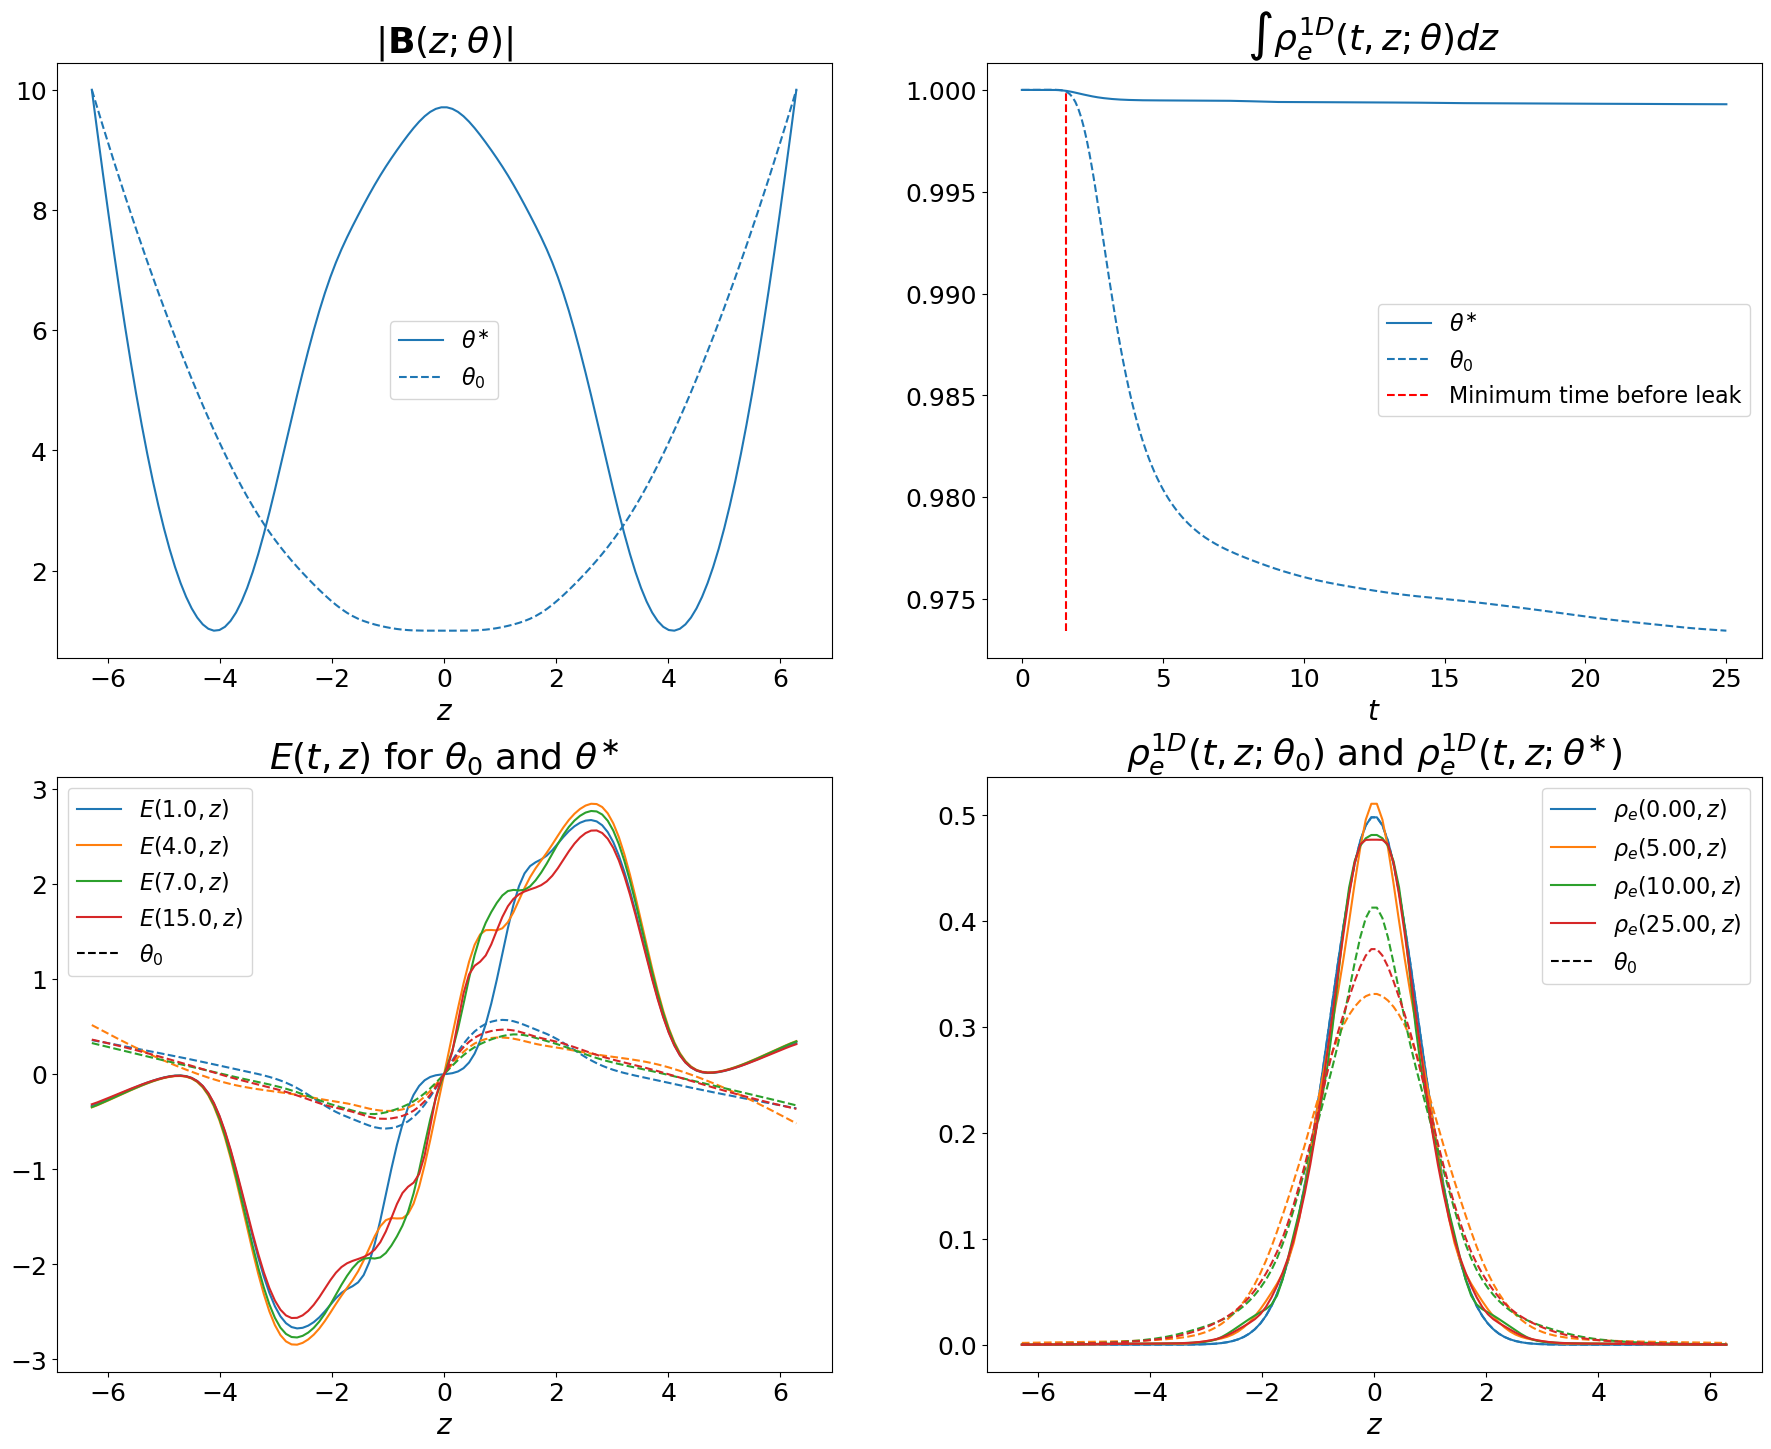

In [19]:
plot_summray_opt_single(B_eval_init, B_eval_opt, t_values, rho_array_init, rho_array_opt, E_array_init, E_array_opt, mesh, LZ, LV)